In [1]:
import requests
import pandas as pd
import numpy as np
from binance.client import Client
import datetime

from itertools import combinations
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm


## Load Data and filter the top 20 by market cap

In [2]:
url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 50,   # pull more so filtering still leaves ~20
    "page": 1,
    "sparkline": False
    
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data)[
    ["market_cap_rank", "symbol", "name", "market_cap", "current_price"]
]

# -----------------------------
# Filters
# -----------------------------

stablecoins = {
    "usdt", "usdc", "busd", "dai", "tusd",
    "usdp", "fdusd", "gusd", "lusd",
    "ust", "ustc", "usdd", "eurc",'usds','usde','bsc-usd','usd1','pyusd'
    
}

# normalize text
df["symbol"] = df["symbol"].str.lower()
df["name"] = df["name"].str.lower()

# remove stablecoins
df = df[~df["symbol"].isin(stablecoins)]

# remove wrapped coins
df = df[
    ~df["name"].str.contains("wrapped") &
    ~df["symbol"].str.startswith("w")
]

# take top 20 after filtering
df = df.sort_values("market_cap", ascending=False).head(20)

print(df)


    market_cap_rank      symbol          name     market_cap  current_price
0                 1         btc       bitcoin  1397774768735   69989.000000
1                 2         eth      ethereum   248887049200    2066.220000
3                 4         bnb           bnb    88950857741     652.620000
4                 5         xrp           xrp    84542957861       1.380000
6                 7         sol        solana    49529465612      86.720000
7                 8         trx          tron    27365719632       0.288842
8                 9  figr_heloc  figure heloc    16222192421       1.027000
9                10        doge      dogecoin    14508552601       0.094715
12               13         ada       cardano     9626759297       0.261491
13               14         bch  bitcoin cash     9158279796     458.650000
14               15        hype   hyperliquid     8971225022      37.560000
15               16         leo     leo token     8298541039       9.010000
16          

## Get symbol from Binance, using binance data and later using binance api for trading test.


In [3]:
binance_symbols = requests.get(
    "https://api.binance.com/api/v3/exchangeInfo"
).json()

binance_assets = {
    s["baseAsset"].lower()
    for s in binance_symbols["symbols"]
    if s["quoteAsset"] == "USDT"
}

df = df[df["symbol"].isin(binance_assets)]

In [4]:
client = Client()


def get_close_prices_15m(
    client,
    symbols,
    start_date,
    end_date
):

    close_dfs = []

    for sym in symbols:
        pair = sym.upper() + "USDT"
        print(f"Downloading {pair}")

        klines = client.get_historical_klines(
            pair,
            Client.KLINE_INTERVAL_15MINUTE,
            start_date.strftime("%d %b %Y %H:%M:%S"),
            end_date.strftime("%d %b %Y %H:%M:%S")
        )

        df = pd.DataFrame(klines, columns=[
            "timestamp", "open", "high", "low", "close", "volume",
            "close_time", "quote_asset_volume", "number_of_trades",
            "taker_buy_base", "taker_buy_quote", "ignore"
        ])

        df = df[["timestamp", "close"]]
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
        df["close"] = df["close"].astype(float)

        df = df.rename(columns={"close": sym.upper()})

        close_dfs.append(df)

    # ---- merge all coins on timestamp ----
    df_close = close_dfs[0]

    for d in close_dfs[1:]:
        df_close = df_close.merge(
            d,
            on="timestamp",
            how="outer"
        )

    df_close = (
        df_close
        .sort_values("timestamp")
        .set_index("timestamp")
    )

    return df_close


In [5]:
#start_date = datetime(2025, 1, 1)
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=30)


df_close_15m = get_close_prices_15m(
    client,
    df['symbol'].tolist(),
    start_date,
    end_date
)

### visualise price change over time

In [6]:
import numpy as np

base = df_close_15m.iloc[0]
bad_cols = base[(base.isna()) | (base == 0)].index
print("Bad columns:", bad_cols)
df_close_15m = df_close_15m.drop(columns=bad_cols)

Bad columns: Index(['XMR'], dtype='object')


Text(0, 0.5, 'Price')

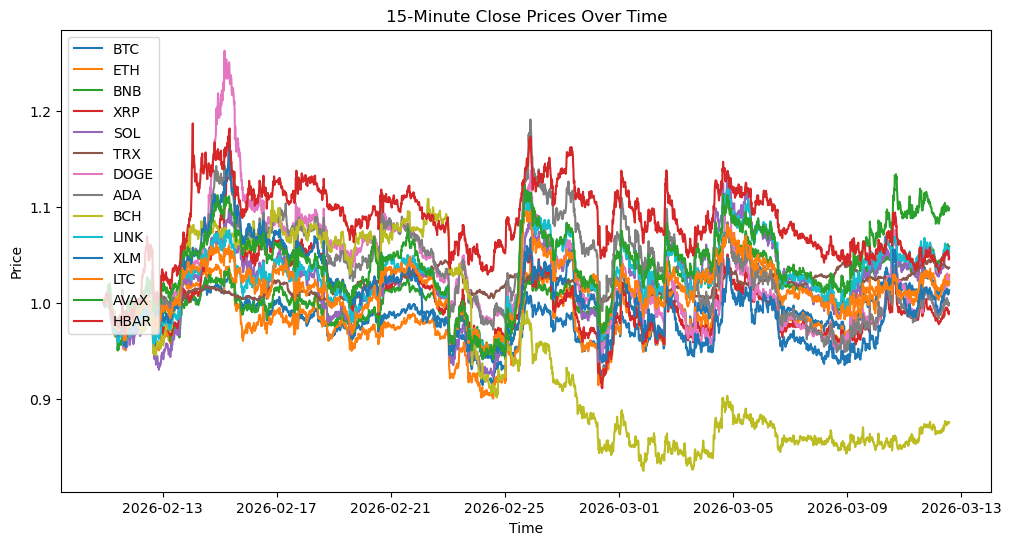

In [7]:
import matplotlib.pyplot as plt

normalized_df = df_close_15m / df_close_15m.iloc[0]  # Normalize to the first row

plt.figure(figsize=(12, 6))
for col in normalized_df.columns:
    plt.plot(normalized_df.index, normalized_df[col], label=col)
plt.legend()
plt.title("15-Minute Close Prices Over Time")
plt.xlabel("Time")
plt.ylabel("Price")

In [8]:
df_close=df_close_15m.copy()

In [9]:
df_close_15m.dropna(inplace=True, axis=0)

In [10]:
df_close_15m

,BTC,ETH,BNB,XRP,SOL,TRX,DOGE,ADA,BCH,LINK,XLM,LTC,AVAX,HBAR
timestamp,,,,,,,,,,,,,,
2026-02-10 22:15:00,68686.95,2014.64,617.67,1.3983,82.65,0.2787,0.09283,0.2624,524.3,8.56,0.1581,53.31,8.73,0.09027
2026-02-10 22:30:00,68665.71,2017.00,619.40,1.4028,82.74,0.2782,0.09292,0.2626,524.6,8.57,0.1586,53.26,8.74,0.09047
2026-02-10 22:45:00,68707.18,2017.95,619.23,1.4000,82.60,0.2784,0.09264,0.2618,524.9,8.55,0.1584,53.22,8.72,0.09019
2026-02-10 23:00:00,68717.98,2017.77,619.06,1.3970,82.56,0.2780,0.09275,0.2616,524.1,8.55,0.1580,53.23,8.71,0.09020
2026-02-10 23:15:00,68663.25,2013.90,618.74,1.3961,82.69,0.2780,0.09272,0.2612,524.3,8.54,0.1579,53.26,8.72,0.09023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-12 13:00:00,70413.04,2065.21,654.76,1.3883,87.30,0.2887,0.09483,0.2628,459.4,9.03,0.1601,54.47,9.60,0.09518
2026-03-12 13:15:00,70111.28,2056.80,653.03,1.3840,86.95,0.2889,0.09450,0.2619,459.1,9.00,0.1595,54.29,9.58,0.09477
2026-03-12 13:30:00,70079.52,2068.41,652.96,1.3856,86.96,0.2887,0.09484,0.2621,459.0,9.02,0.1600,54.40,9.59,0.09476


## Run Cointegration Test
### select BTC related pairs

In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from itertools import combinations

def test_cointegration_kalman(series_x, series_y, delta=1e-4):
    """
    Stationarity test using a Kalman Filter for dynamic hedge ratios
    """
    # 1️⃣ Kalman Filter to calculate rolling Alpha and Beta
    state_mean = np.zeros(2)
    state_cov = np.ones((2, 2))
    
    Q = (delta / (1 - delta)) * np.eye(2) 
    R = 1.0 
    
    rolling_alpha = []
    rolling_beta = []
    
    # Iterate through the time series
    for i in range(len(series_x)):
        x_t = series_x.iloc[i]
        y_t = series_y.iloc[i]
        
        H = np.array([[1.0, x_t]])
        
        # Prediction Step
        state_mean_pred = state_mean
        state_cov_pred = state_cov + Q
        
        # Update Step
        y_pred = H.dot(state_mean_pred)
        error = y_t - y_pred
        
        S = H.dot(state_cov_pred).dot(H.T) + R
        K = state_cov_pred.dot(H.T) / S
        
        state_mean = state_mean_pred + (K.flatten() * error)
        state_cov = (np.eye(2) - K.dot(H)).dot(state_cov_pred)
        
        rolling_alpha.append(state_mean[0])
        rolling_beta.append(state_mean[1])
        
    rolling_alpha = pd.Series(rolling_alpha, index=series_x.index)
    rolling_beta = pd.Series(rolling_beta, index=series_x.index)

    # 2️⃣ Calculate Dynamic Spread
    spread = series_y - (rolling_beta * series_x + rolling_alpha)

    # 3️⃣ Stationarity test (ADF) directly on the dynamic spread
    # We drop NA values that might occur during the initial filter convergence
    adf_result = adfuller(spread.dropna())
    
    t_stat = adf_result[0]
    pvalue = adf_result[1]
    crit_values = adf_result[4]

    return {
        "latest_beta": rolling_beta.iloc[-1], # Return the most recent beta for the summary table
        "pvalue": pvalue,
        "t_stat": t_stat,
        "crit_1%": crit_values['1%'],
        "crit_5%": crit_values['5%'],
        "crit_10%": crit_values['10%'],
        "spread": spread,
        "rolling_beta_series": rolling_beta # Stored in case you need to plot it later
    }

# --- Execution Loop ---
results = []
pairs = list(combinations(normalized_df.columns, 2))

for x, y in pairs:
    res = test_cointegration_kalman(normalized_df[x], normalized_df[y])

    results.append({
        "pair": f"{x}-{y}",
        "x": x,
        "y": y,
        "latest_beta": res["latest_beta"],
        "pvalue": res["pvalue"],
        "t_stat": res["t_stat"],
        "crit_5%": res["crit_5%"]
    })

# Format and filter the results
df_coint = pd.DataFrame(results)
coint_pairs = df_coint[df_coint["pvalue"] < 0.05]
coint_pairs = coint_pairs.sort_values("pvalue")

# Filter for pairs specifically involving BTC
btc_pairs = coint_pairs[
    (coint_pairs["x"] == "BTC") |
    (coint_pairs["y"] == "BTC")
]

display(btc_pairs)

,pair,x,y,latest_beta,pvalue,t_stat,crit_5%
1,BTC-BNB,BTC,BNB,0.534605,2.603060e-20,-11.173646,-2.862556
10,BTC-LTC,BTC,LTC,0.524534,1.708367e-14,-8.837007,-2.862556
8,BTC-LINK,BTC,LINK,0.557923,1.101253e-11,-7.734750,-2.862556
12,BTC-HBAR,BTC,HBAR,0.534488,1.775170e-11,-7.652386,-2.862556
9,BTC-XLM,BTC,XLM,0.524376,6.141854e-11,-7.437114,-2.862556
2,BTC-XRP,BTC,XRP,0.513066,1.691350e-08,-6.431676,-2.862556
4,BTC-TRX,BTC,TRX,0.492687,2.056661e-08,-6.395412,-2.862557
0,BTC-ETH,BTC,ETH,0.540415,3.078874e-08,-6.320241,-2.862556
11,BTC-AVAX,BTC,AVAX,0.577341,3.424258e-07,-5.860223,-2.862556
5,BTC-DOGE,BTC,DOGE,0.535953,3.950245e-06,-5.368135,-2.862565


Analyzing the most cointegrated pair: BTC & BNB


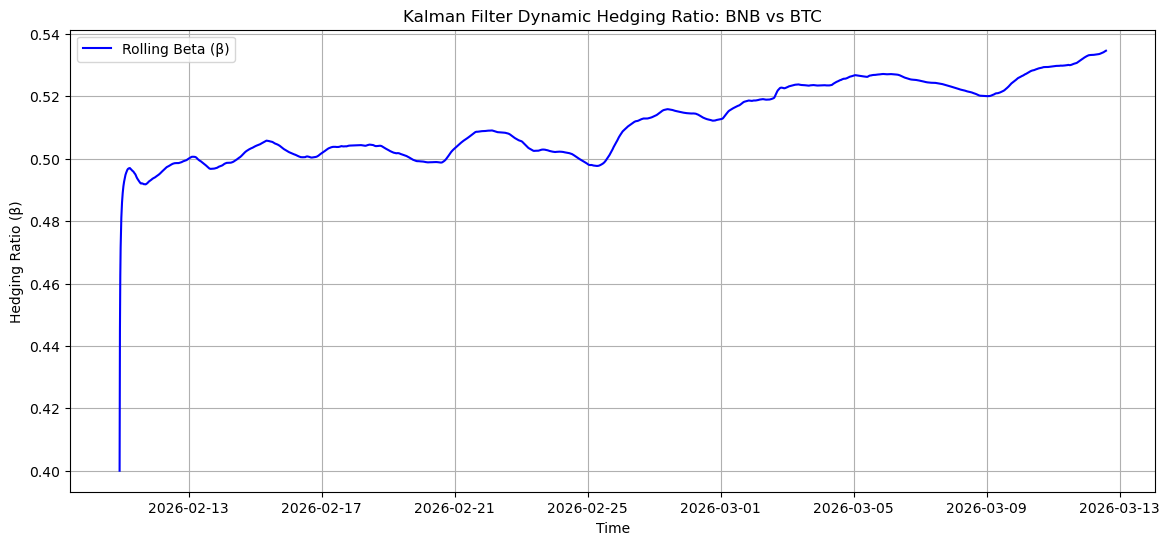

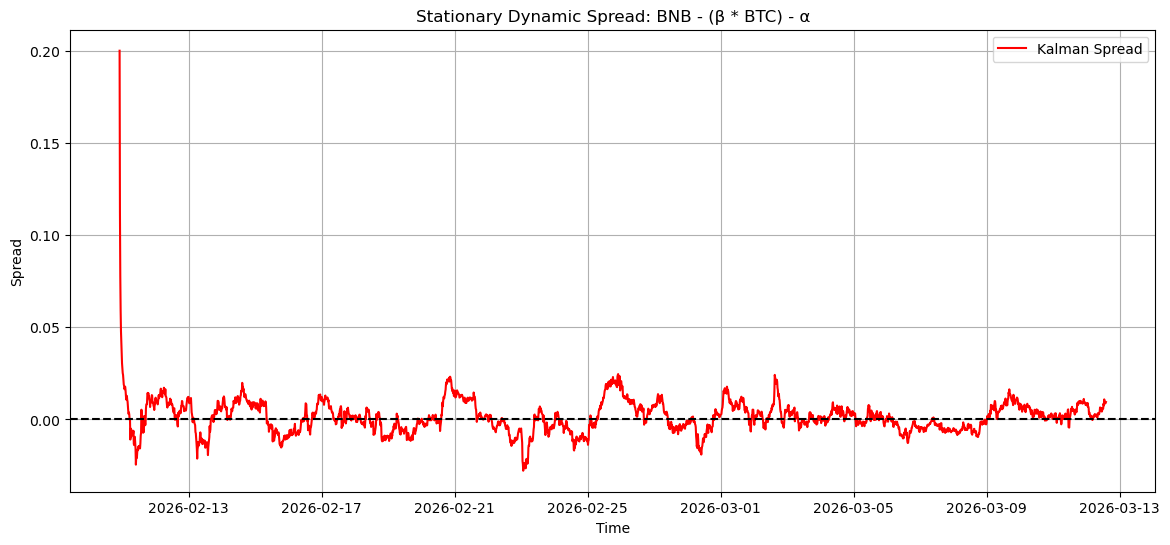

In [12]:
import matplotlib.pyplot as plt

# 1. Select the most cointegrated BTC pair (the one with the lowest p-value)
best_x = btc_pairs.iloc[0]['x']
best_y = btc_pairs.iloc[0]['y']
print(f"Analyzing the most cointegrated pair: {best_x} & {best_y}")

# 2. Re-run the Kalman Filter specifically for this pair to get the full time series
kalman_results = test_cointegration_kalman(normalized_df[best_x], normalized_df[best_y])

rolling_beta = kalman_results["rolling_beta_series"]
dynamic_spread = kalman_results["spread"]

# 3. Plot the Dynamic Hedging Ratio (Beta)
plt.figure(figsize=(14, 6))
plt.plot(rolling_beta.index, rolling_beta, label=f'Rolling Beta (\u03b2)', color='blue')
plt.title(f'Kalman Filter Dynamic Hedging Ratio: {best_y} vs {best_x}')
plt.xlabel('Time')
plt.ylabel('Hedging Ratio (\u03b2)')
plt.legend()
plt.grid(True)
plt.show()

# 4. Plot the resulting Dynamic Spread for visualization
plt.figure(figsize=(14, 6))
plt.plot(dynamic_spread.index, dynamic_spread, label='Kalman Spread', color='red')
plt.axhline(0, color='black', linestyle='--', lw=1.5)
plt.title(f'Stationary Dynamic Spread: {best_y} - (\u03b2 * {best_x}) - \u03b1')
plt.xlabel('Time')
plt.ylabel('Spread')
plt.legend()
plt.grid(True)
plt.show()

## Modelling

In [13]:


def build_spread(prices: pd.DataFrame, x: str, y: str, beta: float, use_log=True):
    px = prices[x].astype(float)
    py = prices[y].astype(float)
    if use_log:
        px = np.log(px)
        py = np.log(py)
    spread = py - beta * px
    return spread.dropna()

In [14]:
def fit_ou_from_spread(spread: pd.Series, delta=1.0):
    s = spread.values
    s_t = s[:-1]
    s_t1 = s[1:]

    X = sm.add_constant(s_t)
    res = sm.OLS(s_t1, X).fit()

    b = float(res.params[0])
    a = float(res.params[1])

    # guardrails
    if not (0 < a < 1):
        return None  # not mean-reverting in discrete-time sense

    eps = res.resid
    sd_eps = float(np.std(eps, ddof=1))

    lam = -np.log(a) / delta
    mu = b / (1 - a)
    sigma = sd_eps * np.sqrt((-2*np.log(a)) / (delta*(1 - a*a)))

    half_life = np.log(2) / lam

    return {
        "a": a, "b": b,
        "lambda": lam,
        "mu": mu,
        "sigma": sigma,
        "half_life": half_life,
        "r2": float(res.rsquared)
    }

In [15]:
def ou_zscore(spread: pd.Series, mu: float, sigma: float):
    return (spread - mu) / sigma

def percentile_signals(z: pd.Series, lookback=24*4, p_low=25, p_high=75, p_exit=50):
    sig = pd.Series(0, index=z.index, dtype=int)

    for i in range(lookback, len(z)):
        hist = z.iloc[i-lookback:i]
        lo = np.percentile(hist, p_low)
        hi = np.percentile(hist, p_high)
        mid = np.percentile(hist, p_exit)

        if z.iloc[i] > hi:
            sig.iloc[i] = -1   # short spread
        elif z.iloc[i] < lo:
            sig.iloc[i] = 1    # long spread
        elif (z.iloc[i-1] - mid) * (z.iloc[i] - mid) <= 0:
            sig.iloc[i] = 0    # exit when cross mid
        else:
            sig.iloc[i] = sig.iloc[i-1]  # hold previous position

    return sig

Regime Detection + Rolling Cointegration
**Goal:** Prevent trading during structural breaks by filtering signals with a regime indicator.

- Rolling ADF test → track rolling p-value and t-stat
- Rolling half-life → detect when mean-reversion breaks down
- Regime signal: 1 = allow trading (green light), 0 = halt trading (red light)

In [16]:
def generate_regime_signals(kalman_spread, window=200, step=5,
                             p_val_threshold=0.1, max_halflife=200):
    """
    Jiayi's Regime Detection Module.

    Rolls a window over the Kalman spread and at each step computes:
      1. ADF test  -> rolling p-value and t-stat
      2. OU half-life via OLS regression on delta_spread ~ spread_lag

    Regime rule:
      GREEN (1): p-value < threshold  AND  0 < half-life < max_halflife
      RED   (0): otherwise (structural break or spread not mean-reverting)

    Parameters
    ----------
    kalman_spread     : pd.Series  – dynamic spread from Weisiang's Kalman filter
    window            : int        – look-back window in bars (200 bars ≈ 50 hrs on 15-min data)
    step              : int        – re-compute every `step` bars (speeds up the loop)
    p_val_threshold   : float      – ADF p-value cut-off (default 0.10)
    max_halflife      : int        – max acceptable half-life in bars (200 ≈ 50 hrs)

    Returns
    -------
    pd.DataFrame with columns: p_value, t_stat, half_life, regime_signal
    """
    results = pd.DataFrame(index=kalman_spread.index)
    results['p_value']       = np.nan
    results['t_stat']        = np.nan
    results['half_life']     = np.nan
    results['regime_signal'] = np.nan

    for i in range(window, len(kalman_spread), step):
        current_spread = kalman_spread.iloc[i - window : i]
        idx = current_spread.index[-1]

        # ── 1. Rolling ADF test ───────────────────────────────────────────
        try:
            from statsmodels.tsa.stattools import adfuller
            adf_res        = adfuller(current_spread, maxlag=1, autolag=None)
            p_val, t_stat  = adf_res[1], adf_res[0]
        except Exception as e:
            print(f"ADF error at {idx}: {e}")
            p_val, t_stat  = 1.0, 0.0

        results.loc[idx, 'p_value'] = p_val
        results.loc[idx, 't_stat']  = t_stat

        # ── 2. Rolling half-life (OU via OLS) ────────────────────────────
        # Regression: Δspread_t = λ * spread_{t-1} + ε
        # half-life  = -ln(2) / λ   (λ must be negative for mean-reversion)
        try:
            y        = current_spread.values
            y_lag    = y[:-1]
            delta_y  = y[1:] - y_lag
            lam      = sm.OLS(delta_y, sm.add_constant(y_lag)).fit().params[1]
            half_life = -np.log(2) / lam if lam < 0 else np.inf
        except Exception as e:
            print(f"Half-life error at {idx}: {e}")
            half_life = np.inf

        results.loc[idx, 'half_life'] = half_life

        # ── 3. Regime rule ───────────────────────────────────────────────
        if (p_val < p_val_threshold) and (0 < half_life < max_halflife):
            results.loc[idx, 'regime_signal'] = 1   # green – allow trading
        else:
            results.loc[idx, 'regime_signal'] = 0   # red   – halt trading

    # Forward-fill between computation steps; default to 0 (red) at the start
    results['regime_signal'] = (
        results['regime_signal']
        .ffill()
        .fillna(0)
        .astype(int)
    )
    return results

In [17]:
def walk_forward_signals(prices, x, y, train_window, trade_window):
    """
    Walk‑forward signal generation using the Kalman‑derived hedge ratio
    from the training window.
    """
    signals = []
    z_scores = []

    for start in range(train_window, len(prices) - trade_window, trade_window):
        train = prices.iloc[start - train_window:start]
        test  = prices.iloc[start:start + trade_window]

        # ---- 1. Obtain Kalman beta from training window ----
        # test_cointegration_kalman returns a dict with 'latest_beta'
        kalman_res = test_cointegration_kalman(train[x], train[y])
        beta = kalman_res["latest_beta"]   # float, final hedge ratio

        # ---- 2. Build spread using this beta ----
        spread_train = train[y] - beta * train[x]

        # ---- 3. Fit OU process to the spread ----
        ou = fit_ou_from_spread(spread_train)
        if ou is None:
            # Skip this window if OU parameters are invalid
            continue

        # ---- 4. Compute z‑score on test window ----
        spread_test = test[y] - beta * test[x]
        z = ou_zscore(spread_test, ou["mu"], ou["sigma"])

        # ---- 5. Generate trading signals ----
        lookback = max(10, len(z) // 4)   # at most 1/4 of test window
        sig = percentile_signals(z, lookback=lookback)

        signals.append(sig)
        z_scores.append(z)

    if not signals:
        # Return empty series if no windows succeeded
        return pd.Series(dtype=float), pd.Series(dtype=int)

    signals = pd.concat(signals)
    z_scores = pd.concat(z_scores)
    return z_scores, signals

In [18]:
def run_ou_for_pairs(pairs_df: pd.DataFrame, prices: pd.DataFrame, delta=1.0):
    results = []

    for _, row in pairs_df.iterrows():
        x, y, beta = row["x"], row["y"], float(row["latest_beta"])

        z, sig = walk_forward_signals(prices=df_close_15m, x=x, y=y,train_window=24*4*25,trade_window=24*4) # 20 days train, 1 day test

        results.append({
            "pair": f"{x}-{y}",
            "beta": beta,
            'z_scores' : z,
            "signal": sig
        })

    return results

In [19]:
ou_results = run_ou_for_pairs(btc_pairs, df_close_15m)

In [20]:
ou_results

[{'pair': 'BTC-BNB',
  'beta': 0.5346053704310907,
  'z_scores': timestamp
  2026-03-07 22:15:00    3.110839
  2026-03-07 22:30:00    3.701127
  2026-03-07 22:45:00    3.573326
  2026-03-07 23:00:00    3.112876
  2026-03-07 23:15:00    2.862813
                           ...   
  2026-03-11 21:00:00    4.565088
  2026-03-11 21:15:00    4.707854
  2026-03-11 21:30:00    5.340721
  2026-03-11 21:45:00    4.773242
  2026-03-11 22:00:00    5.385601
  Length: 384, dtype: float64,
  'signal': timestamp
  2026-03-07 22:15:00    0
  2026-03-07 22:30:00    0
  2026-03-07 22:45:00    0
  2026-03-07 23:00:00    0
  2026-03-07 23:15:00    0
                        ..
  2026-03-11 21:00:00   -1
  2026-03-11 21:15:00   -1
  2026-03-11 21:30:00   -1
  2026-03-11 21:45:00   -1
  2026-03-11 22:00:00   -1
  Length: 384, dtype: int64},
 {'pair': 'BTC-LTC',
  'beta': 0.5245339111748231,
  'z_scores': timestamp
  2026-03-07 22:15:00    -4.863404
  2026-03-07 22:30:00    -4.050813
  2026-03-07 22:45:00    -

In [21]:

ou_df = pd.DataFrame([
    {
        "pair": r["pair"],
        "beta": r["beta"],
        "z_scores": r["z_scores"]
        
    }
    for r in ou_results
])




In [22]:
signals_df = pd.concat(
    {r["pair"]: r["signal"] for r in ou_results},
    axis=1
).sort_index()

In [23]:
signals_df

,BTC-BNB,BTC-LTC,BTC-LINK,BTC-HBAR,BTC-XLM,BTC-XRP,BTC-TRX,BTC-ETH,BTC-AVAX,BTC-DOGE,BTC-SOL,BTC-ADA,BTC-BCH
timestamp,,,,,,,,,,,,,
2026-03-07 22:15:00,0,0,0,0,0,0,0,0,0,0,0,0,0
2026-03-07 22:30:00,0,0,0,0,0,0,0,0,0,0,0,0,0
2026-03-07 22:45:00,0,0,0,0,0,0,0,0,0,0,0,0,0
2026-03-07 23:00:00,0,0,0,0,0,0,0,0,0,0,0,0,0
2026-03-07 23:15:00,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-11 21:00:00,-1,0,0,-1,-1,0,-1,-1,0,-1,-1,0,0
2026-03-11 21:15:00,-1,-1,0,-1,-1,0,-1,-1,1,0,-1,0,-1
2026-03-11 21:30:00,-1,-1,0,-1,-1,0,-1,-1,1,0,-1,0,-1


In [24]:


# -----------------------------
# Helpers: performance metrics
# -----------------------------
def _max_drawdown(equity: pd.Series) -> float:
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())

def _sharpe(returns: pd.Series, bars_per_year: int) -> float:
    r = returns.dropna()
    if len(r) < 2:
        return np.nan
    mu = r.mean()
    sd = r.std(ddof=1)
    if sd == 0:
        return np.nan
    return float((mu / sd) * np.sqrt(bars_per_year))

def _trade_stats(signal: pd.Series, pnl: pd.Series):
    """
    Approx trade stats using "position episodes" (when signal != 0).
    """
    s = signal.fillna(0).astype(int)
    pnl = pnl.fillna(0.0)

    # Episode start: 0 -> +/-1 ; Episode end: +/-1 -> 0 or sign flip
    changes = s.diff().fillna(s.iloc[0]).astype(int)

    # indices where a new position is entered
    entry_idx = s[(s != 0) & (changes != 0)].index
    # indices where position is exited (or flipped)
    exit_idx = s[(s == 0) & (changes != 0)].index

    # If last trade is still open, ignore it for winrate stats
    # Build episodes by walking entries and matching next exit
    episodes = []
    for ei in entry_idx:
        # find first exit after entry
        exits_after = exit_idx[exit_idx > ei]
        if len(exits_after) == 0:
            break
        xo = exits_after[0]
        ep_pnl = pnl.loc[ei:xo].sum()
        episodes.append(ep_pnl)

    if len(episodes) == 0:
        return {
            "num_trades": 0,
            "win_rate": np.nan,
            "avg_trade_pnl": np.nan,
            "median_trade_pnl": np.nan,
            "profit_factor": np.nan,
        }

    ep = np.array(episodes, dtype=float)
    wins = ep[ep > 0]
    losses = ep[ep < 0]

    profit_factor = np.nan
    if losses.size > 0:
        profit_factor = wins.sum() / (-losses.sum()) if wins.size > 0 else 0.0

    return {
        "num_trades": int(len(ep)),
        "win_rate": float((ep > 0).mean()),
        "avg_trade_pnl": float(ep.mean()),
        "median_trade_pnl": float(np.median(ep)),
        "profit_factor": float(profit_factor) if not np.isnan(profit_factor) else np.nan,
    }



In [25]:

# -----------------------------
# Core: perp pair backtester
# -----------------------------
def backtest_pair_perps(
    prices: pd.DataFrame,
    x: str,
    y: str,
    beta: float,
    signal: pd.Series,
    *,
    initial_capital: float = 10_000.0,
    leverage: float = 3.0,
    alloc: float = 1.0,                 # fraction of equity used for gross notional (before leverage)
    fee_rate: float = 0.0004,           # e.g. 4 bps taker; adjust for your assumed execution
    slippage_bps: float = 1.0,          # extra bps per notional traded (0..)
    bars_per_year: int = 365 * 24 * 4,  # 15m bars
    allow_flip_same_bar: bool = True,
) -> dict:
    """
    Signal convention (same as your notebook):
      +1 = long spread  -> LONG y, SHORT x * beta
      -1 = short spread -> SHORT y, LONG x * beta
       0 = flat

    PnL is linear perp-style:
      PnL_t = pos_units_prev * (price_t - price_{t-1}) summed across legs
    Fees/slippage are charged on traded NOTIONAL when position changes.
    """

    # Align & clean
    px = prices[x].astype(float).copy()
    py = prices[y].astype(float).copy()
    df = pd.concat([px.rename("px"), py.rename("py"), signal.rename("sig")], axis=1).dropna()
    df["sig"] = df["sig"].astype(int)

    if len(df) < 5:
        return {"pair": f"{x}-{y}", "df": df, "stats": {"error": "not enough data"}}

    # Containers
    equity = np.zeros(len(df), dtype=float)
    pnl = np.zeros(len(df), dtype=float)
    fees = np.zeros(len(df), dtype=float)

    # Position units (contracts) on each leg
    ux = np.zeros(len(df), dtype=float)
    uy = np.zeros(len(df), dtype=float)

    equity[0] = initial_capital

    prev_sig = 0
    prev_ux = 0.0
    prev_uy = 0.0

    # We use absolute beta weight for notional split
    w_x = abs(beta)
    w_y = 1.0
    denom = (w_x + w_y) if (w_x + w_y) != 0 else 1.0

    for i in range(1, len(df)):
        px_prev, py_prev = float(df["px"].iloc[i - 1]), float(df["py"].iloc[i - 1])
        px_now,  py_now  = float(df["px"].iloc[i]),     float(df["py"].iloc[i])
        sig_now = int(df["sig"].iloc[i])

        # 1) Mark-to-market from previous holdings
        mtm = prev_ux * (px_now - px_prev) + prev_uy * (py_now - py_prev)
        pnl[i] = mtm
        equity[i] = equity[i - 1] + mtm

        # 2) Decide target position (units) based on signal
        #    Notional sizing uses current equity AFTER mtm.
        #    Gross notional = equity * alloc * leverage
        gross = max(equity[i], 0.0) * float(alloc) * float(leverage)

        # Target notionals per leg (split by weights)
        ny = gross * (w_y / denom)
        nx = gross * (w_x / denom)

        # Convert to units (linear perp): units = notional / price
        if sig_now == 0:
            tgt_ux, tgt_uy = 0.0, 0.0
        elif sig_now == 1:
            # long spread: long y, short x*beta
            tgt_uy = + (ny / py_now)
            tgt_ux = - np.sign(beta) * (nx / px_now)  # beta sign determines hedge direction
        else:  # sig_now == -1
            tgt_uy = - (ny / py_now)
            tgt_ux = + np.sign(beta) * (nx / px_now)

        # 3) Trading costs if position changes
        # If you don't want flip-in-same-bar behavior, you can disallow it.
        changed = (sig_now != prev_sig)
        if changed and (not allow_flip_same_bar) and (prev_sig != 0) and (sig_now != 0):
            # force to flat first; then next bar will enter new side
            tgt_ux, tgt_uy = 0.0, 0.0
            sig_now = 0

        dx = tgt_ux - prev_ux
        dy = tgt_uy - prev_uy

        traded_notional = abs(dx) * px_now + abs(dy) * py_now
        cost = traded_notional * (fee_rate + (slippage_bps / 10_000.0))

        fees[i] = cost
        equity[i] -= cost  # deduct costs

        # 4) Set positions for next bar
        ux[i] = tgt_ux
        uy[i] = tgt_uy
        prev_ux, prev_uy = tgt_ux, tgt_uy
        prev_sig = int(df["sig"].iloc[i])

    out = df.copy()
    out["ux"] = ux
    out["uy"] = uy
    out["pnl"] = pnl
    out["fees"] = fees
    out["equity"] = equity
    out["ret"] = out["equity"].pct_change().fillna(0.0)

    # Turnover: traded notional / equity (rough)
    traded = (out["ux"].diff().abs() * out["px"] + out["uy"].diff().abs() * out["py"]).fillna(0.0)
    out["turnover"] = traded / out["equity"].replace(0, np.nan)

    stats = {
        "pair": f"{x}-{y}",
        "beta": float(beta),
        "initial_capital": float(initial_capital),
        "final_equity": float(out["equity"].iloc[-1]),
        "total_pnl": float(out["pnl"].sum() - out["fees"].sum()),
        "gross_pnl": float(out["pnl"].sum()),
        "total_fees": float(out["fees"].sum()),
        "sharpe": _sharpe(out["ret"], bars_per_year=bars_per_year),
        "max_drawdown": _max_drawdown(out["equity"]),
        "avg_turnover": float(out["turnover"].replace([np.inf, -np.inf], np.nan).dropna().mean())
                        if out["turnover"].notna().any() else np.nan,
    }
    stats.update(_trade_stats(out["sig"], out["pnl"] - out["fees"]))

    return {"pair": f"{x}-{y}", "df": out, "stats": stats}



In [26]:

# -----------------------------
# Run it on your ou_results
# -----------------------------
all_stats = []
bt_results = {}

for r in ou_results:
    pair = r["pair"]          # e.g. "BTC-ETH"
    beta = r["beta"]
    sig = r["signal"]         # pd.Series indexed by timestamp (test period)

    x, y = pair.split("-")
    res = backtest_pair_perps(
        prices=df_close_15m,
        x=x, y=y,
        beta=beta,
        signal=sig,
        initial_capital=10_000,
        leverage=3.0,
        alloc=1,
        fee_rate=0.0004,
        slippage_bps=1.0,
        bars_per_year=365*24*4,  # 15m
    )

    bt_results[pair] = res
    all_stats.append(res["stats"])

stats_df = pd.DataFrame(all_stats).sort_values("sharpe", ascending=False)
stats_df

,pair,beta,initial_capital,final_equity,total_pnl,gross_pnl,total_fees,sharpe,max_drawdown,avg_turnover,num_trades,win_rate,avg_trade_pnl,median_trade_pnl,profit_factor
2,BTC-LINK,0.557923,10000.0,10896.286834,896.286834,2018.108027,1121.821193,12.442551,-0.041530,0.552437,35,0.742857,41.408079,36.582128,3.387033
7,BTC-ETH,0.540415,10000.0,10341.684484,341.684484,1171.529337,829.844854,5.352391,-0.040811,0.419753,26,0.615385,36.587307,28.094949,3.439846
11,BTC-ADA,0.525683,10000.0,10427.675013,427.675013,1004.370025,576.695012,5.143801,-0.074593,0.289262,18,0.611111,57.788791,61.958943,2.147738
10,BTC-SOL,0.560795,10000.0,10089.345435,89.345435,844.643572,755.298137,1.490681,-0.042036,0.389586,24,0.583333,29.284689,31.448759,1.774787
8,BTC-AVAX,0.577341,10000.0,9903.080948,-96.919052,649.828240,746.747292,-0.566443,-0.077857,0.391973,24,0.458333,-1.957142,-13.338601,0.962613
5,BTC-XRP,0.513066,10000.0,9648.999838,-351.000162,271.709096,622.709258,-4.742192,-0.064676,0.334736,21,0.380952,-14.507436,-34.293781,0.753329
9,BTC-DOGE,0.535953,10000.0,9372.443169,-627.556831,-54.737869,572.818962,-5.668827,-0.129499,0.304496,19,0.526316,-56.582446,36.374649,0.492963
3,BTC-HBAR,0.534488,10000.0,9336.375950,-663.624050,-253.277520,410.346530,-8.935382,-0.099270,0.217498,13,0.307692,-66.097346,-65.494486,0.211842
1,BTC-LTC,0.524534,10000.0,9323.480240,-676.519760,39.146682,715.666442,-11.885711,-0.072955,0.388629,24,0.333333,-26.856824,-8.888318,0.306762
0,BTC-BNB,0.534605,10000.0,9467.746243,-532.253757,276.794535,809.048293,-12.606009,-0.059018,0.434585,27,0.296296,-29.544468,-28.952183,0.340002


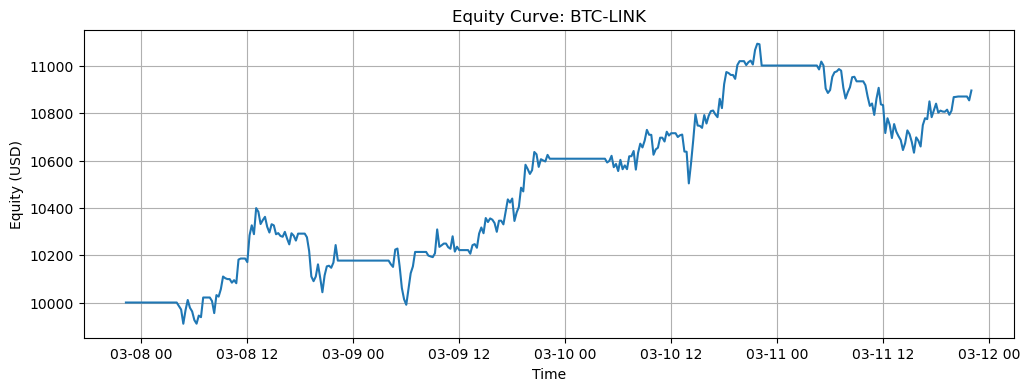

{'pair': 'BTC-LINK',
 'beta': 0.5579227267227524,
 'initial_capital': 10000.0,
 'final_equity': 10896.286834404857,
 'total_pnl': 896.2868344048652,
 'gross_pnl': 2018.108026984948,
 'total_fees': 1121.8211925800829,
 'sharpe': 12.442551227580916,
 'max_drawdown': -0.04153038597866787,
 'avg_turnover': 0.5524369517663715,
 'num_trades': 35,
 'win_rate': 0.7428571428571429,
 'avg_trade_pnl': 41.40807908890936,
 'median_trade_pnl': 36.58212839450222,
 'profit_factor': 3.387033270568648}

In [27]:
import matplotlib.pyplot as plt

best_pair = stats_df.iloc[0]["pair"]
eq = bt_results[best_pair]["df"]["equity"]

plt.figure(figsize=(12,4))
plt.plot(eq.index, eq.values)
plt.title(f"Equity Curve: {best_pair}")
plt.xlabel("Time")
plt.ylabel("Equity (USD)")
plt.grid(True)
plt.show()

bt_results[best_pair]["stats"]

Regime Filter – Backtest Comparison
Compare P&L **with** vs **without** regime detection across all BTC pairs.

Running regime detection on BTC-BNB spread (2848 bars)...


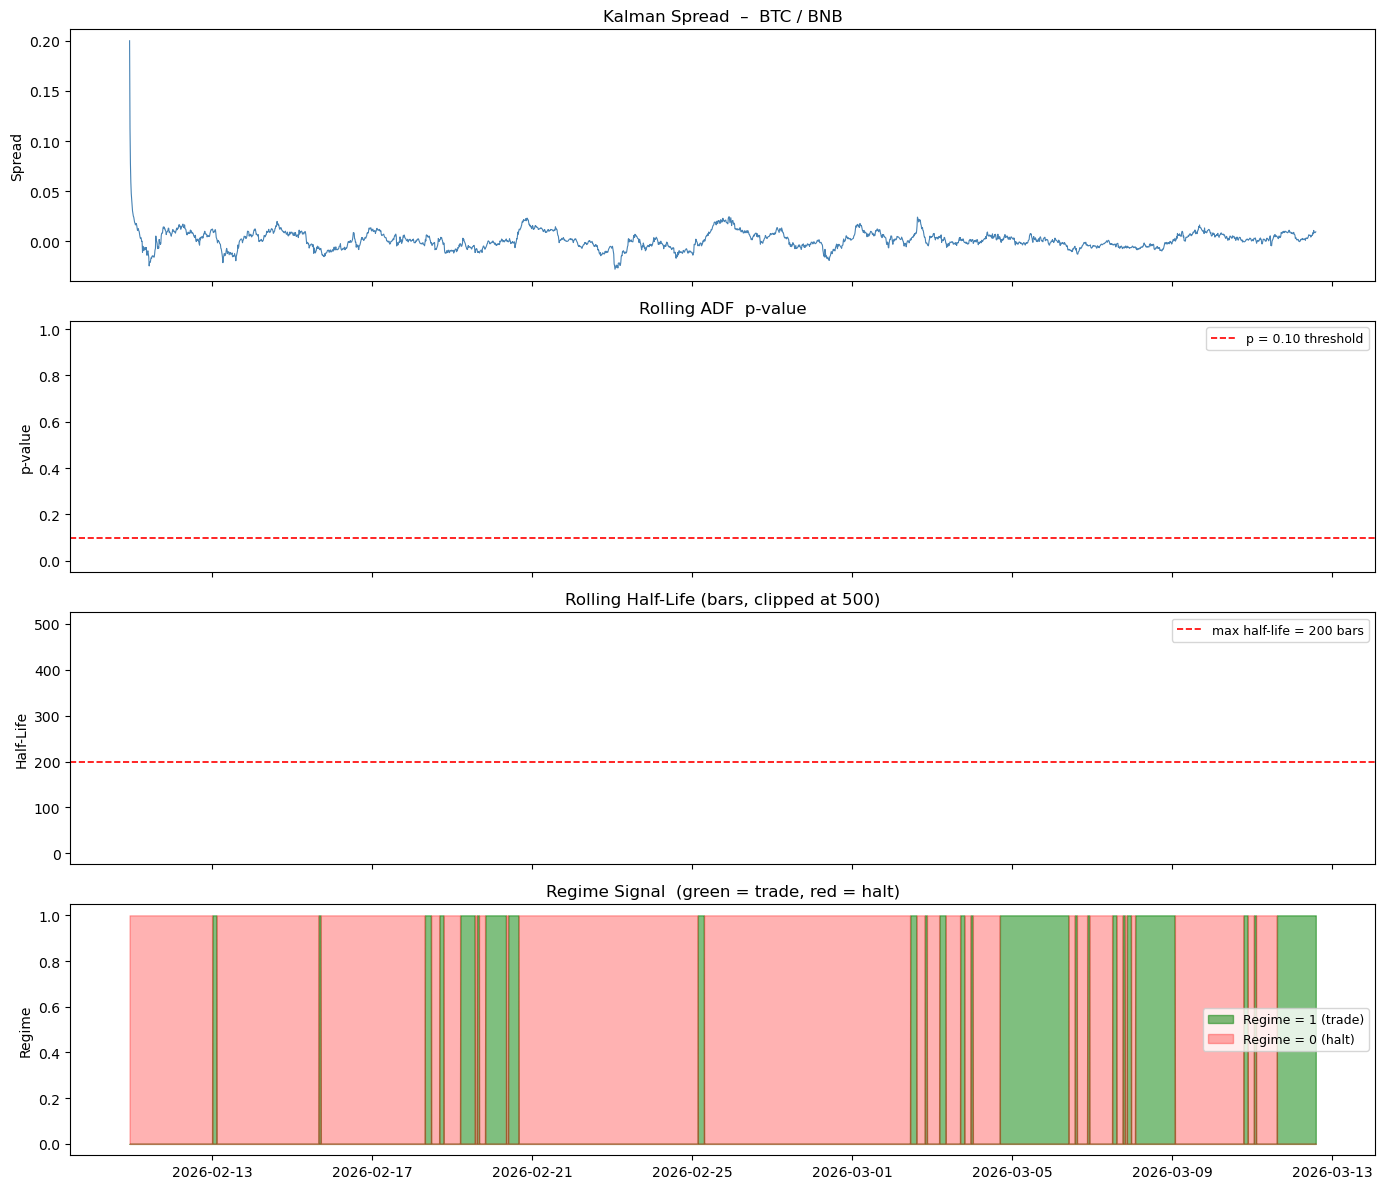


Time allowed to trade: 21.9%


In [28]:
# ── Visualise rolling regime diagnostics for the best pair ──────────────────
best_pair_x = btc_pairs.iloc[0]['x']
best_pair_y = btc_pairs.iloc[0]['y']

kalman_res_best   = test_cointegration_kalman(normalized_df[best_pair_x], normalized_df[best_pair_y])
kalman_spread_best = kalman_res_best["spread"]

print(f"Running regime detection on {best_pair_x}-{best_pair_y} spread ({len(kalman_spread_best)} bars)...")
regime_df_best = generate_regime_signals(kalman_spread_best)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(kalman_spread_best.index, kalman_spread_best, color='steelblue', lw=0.8)
axes[0].set_title(f'Kalman Spread  –  {best_pair_x} / {best_pair_y}')
axes[0].set_ylabel('Spread')

axes[1].plot(regime_df_best.index, regime_df_best['p_value'], color='darkorange', lw=0.8)
axes[1].axhline(0.1, color='red', linestyle='--', lw=1.2, label='p = 0.10 threshold')
axes[1].set_title('Rolling ADF  p-value')
axes[1].set_ylabel('p-value')
axes[1].legend(fontsize=9)

axes[2].plot(regime_df_best.index, regime_df_best['half_life'].clip(upper=500),
             color='purple', lw=0.8)
axes[2].axhline(200, color='red', linestyle='--', lw=1.2, label='max half-life = 200 bars')
axes[2].set_title('Rolling Half-Life (bars, clipped at 500)')
axes[2].set_ylabel('Half-Life')
axes[2].legend(fontsize=9)

axes[3].fill_between(regime_df_best.index, regime_df_best['regime_signal'],
                     color='green', alpha=0.5, label='Regime = 1 (trade)')
axes[3].fill_between(regime_df_best.index,
                     (regime_df_best['regime_signal'] == 0).astype(int),
                     color='red', alpha=0.3, label='Regime = 0 (halt)')
axes[3].set_title('Regime Signal  (green = trade, red = halt)')
axes[3].set_ylabel('Regime')
axes[3].legend(fontsize=9)

plt.tight_layout()
plt.show()

pct_green = regime_df_best['regime_signal'].mean() * 100
print(f"\nTime allowed to trade: {pct_green:.1f}%")

In [29]:
# ── Run backtest WITH and WITHOUT regime filter for all BTC pairs ────────────
all_stats_no_regime   = []
all_stats_with_regime = []
bt_no_regime   = {}
bt_with_regime = {}

for r in ou_results:
    pair = r["pair"]
    beta = r["beta"]
    sig  = r["signal"]
    x, y = pair.split("-")

    # Re-compute Kalman spread for this pair
    kr     = test_cointegration_kalman(normalized_df[x], normalized_df[y])
    k_spread = kr["spread"]

    # Generate regime signal for this pair
    rdf    = generate_regime_signals(k_spread)
    regime = rdf['regime_signal'].reindex(sig.index).ffill().fillna(0).astype(int)

    # Filtered signal: zero out trades when regime == 0
    sig_filtered = sig * regime

    # ── Backtest WITHOUT regime ───────────────────────────────────────────
    res_no = backtest_pair_perps(
        prices=df_close_15m, x=x, y=y, beta=beta, signal=sig,
        initial_capital=10_000, leverage=3.0, alloc=1,
        fee_rate=0.0004, slippage_bps=1.0, bars_per_year=365*24*4,
    )
    bt_no_regime[pair] = res_no
    all_stats_no_regime.append(res_no["stats"])

    # ── Backtest WITH regime ──────────────────────────────────────────────
    res_w = backtest_pair_perps(
        prices=df_close_15m, x=x, y=y, beta=beta, signal=sig_filtered,
        initial_capital=10_000, leverage=3.0, alloc=1,
        fee_rate=0.0004, slippage_bps=1.0, bars_per_year=365*24*4,
    )
    bt_with_regime[pair] = res_w
    all_stats_with_regime.append(res_w["stats"])

# ── Comparison table ──────────────────────────────────────────────────────────
cols = ["sharpe", "max_drawdown", "total_pnl", "num_trades", "win_rate"]

df_no = (pd.DataFrame(all_stats_no_regime)
           .set_index("pair")[cols]
           .rename(columns=lambda c: c + "_no_regime"))

df_w  = (pd.DataFrame(all_stats_with_regime)
           .set_index("pair")[cols]
           .rename(columns=lambda c: c + "_with_regime"))

df_cmp = df_no.join(df_w).sort_values("sharpe_with_regime", ascending=False)
print("=== Regime Filter Comparison ===")
display(df_cmp)

=== Regime Filter Comparison ===


,sharpe_no_regime,max_drawdown_no_regime,total_pnl_no_regime,num_trades_no_regime,win_rate_no_regime,sharpe_with_regime,max_drawdown_with_regime,total_pnl_with_regime,num_trades_with_regime,win_rate_with_regime
pair,,,,,,,,,,
BTC-ADA,5.143801,-0.074593,427.675013,18,0.611111,5.691073,-0.029327,302.523849,12,0.583333
BTC-LINK,12.442551,-0.041530,896.286834,35,0.742857,4.626424,-0.031997,187.651466,20,0.700000
BTC-DOGE,-5.668827,-0.129499,-627.556831,19,0.526316,0.464526,-0.051095,11.833869,8,0.625000
BTC-XRP,-4.742192,-0.064676,-351.000162,21,0.380952,-0.936036,-0.042521,-54.992428,9,0.444444
BTC-AVAX,-0.566443,-0.077857,-96.919052,24,0.458333,-1.842473,-0.065630,-135.706019,16,0.562500
BTC-LTC,-11.885711,-0.072955,-676.519760,24,0.333333,-5.050959,-0.036605,-193.042333,13,0.307692
BTC-SOL,1.490681,-0.042036,89.345435,24,0.583333,-6.596776,-0.038260,-254.270447,9,0.333333
BTC-XLM,-15.973448,-0.203974,-1437.456123,21,0.428571,-9.013121,-0.082655,-496.182935,12,0.416667
BTC-ETH,5.352391,-0.040811,341.684484,26,0.615385,-11.501571,-0.032608,-316.070450,12,0.416667


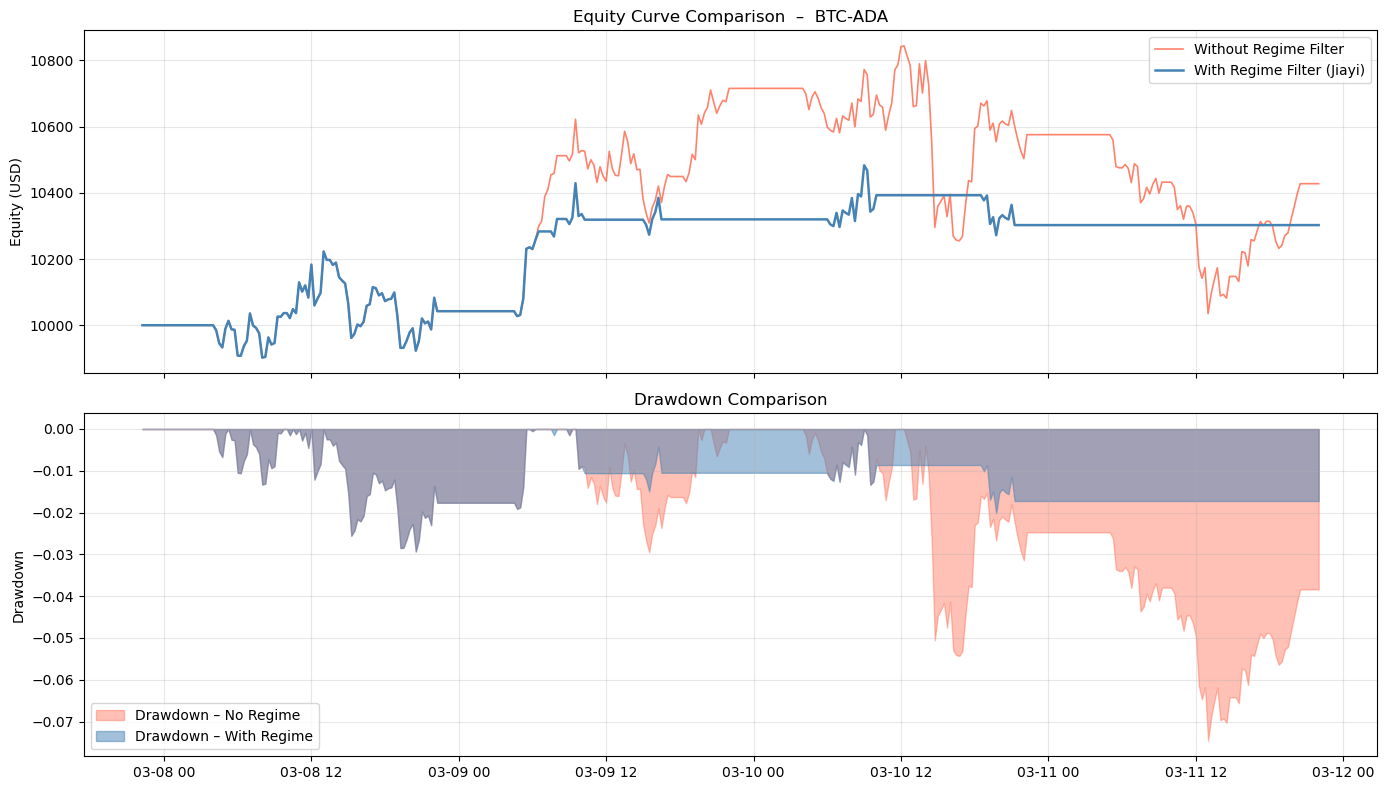


Metric                     No Regime     With Regime
----------------------------------------------------
sharpe                        5.1438          5.6911
max_drawdown                 -0.0746         -0.0293
total_pnl                   427.6750        302.5238
num_trades                   18.0000         12.0000
win_rate                      0.6111          0.5833


In [30]:
# ── Equity curve comparison for the best pair ────────────────────────────────
best_pair = df_cmp["sharpe_with_regime"].idxmax()

eq_no = bt_no_regime[best_pair]["df"]["equity"]
eq_w  = bt_with_regime[best_pair]["df"]["equity"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top panel: equity curves
axes[0].plot(eq_no.index, eq_no.values,
             label="Without Regime Filter", color="tomato", alpha=0.8, lw=1.2)
axes[0].plot(eq_w.index,  eq_w.values,
             label="With Regime Filter (Jiayi)", color="steelblue", lw=1.8)
axes[0].set_title(f"Equity Curve Comparison  –  {best_pair}")
axes[0].set_ylabel("Equity (USD)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom panel: drawdown comparison
def rolling_drawdown(eq):
    peak = eq.cummax()
    return (eq - peak) / peak

dd_no = rolling_drawdown(eq_no)
dd_w  = rolling_drawdown(eq_w)

axes[1].fill_between(dd_no.index, dd_no.values, 0,
                     color="tomato", alpha=0.4, label="Drawdown – No Regime")
axes[1].fill_between(dd_w.index,  dd_w.values,  0,
                     color="steelblue", alpha=0.5, label="Drawdown – With Regime")
axes[1].set_title("Drawdown Comparison")
axes[1].set_ylabel("Drawdown")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats for the best pair
s_no = bt_no_regime[best_pair]["stats"]
s_w  = bt_with_regime[best_pair]["stats"]

print(f"\n{'Metric':<20} {'No Regime':>15} {'With Regime':>15}")
print("-" * 52)
for k in ["sharpe", "max_drawdown", "total_pnl", "num_trades", "win_rate"]:
    v_no = s_no.get(k, float('nan'))
    v_w  = s_w.get(k, float('nan'))
    print(f"{k:<20} {v_no:>15.4f} {v_w:>15.4f}")

In [31]:
def build_trade_log(bt_df: pd.DataFrame):

    trades = []
    position = 0
    entry_time = None
    entry_px = None
    entry_py = None

    for i in range(1, len(bt_df)):

        sig_prev = bt_df["sig"].iloc[i-1]
        sig_now  = bt_df["sig"].iloc[i]

        px = bt_df["px"].iloc[i]
        py = bt_df["py"].iloc[i]
        time = bt_df.index[i]

        # ENTRY
        if position == 0 and sig_now != 0:
            position = sig_now
            entry_time = time
            entry_px = px
            entry_py = py

        # EXIT
        elif position != 0 and sig_now == 0:

            exit_time = time
            exit_px = px
            exit_py = py

            pnl = bt_df.loc[entry_time:exit_time, "pnl"].sum() \
                  - bt_df.loc[entry_time:exit_time, "fees"].sum()

            trades.append({
                "entry_time": entry_time,
                "exit_time": exit_time,
                "direction": "long_spread" if position == 1 else "short_spread",
                "entry_px_x": entry_px,
                "entry_px_y": entry_py,
                "exit_px_x": exit_px,
                "exit_px_y": exit_py,
                "holding_minutes": (exit_time - entry_time).total_seconds() / 60,
                "pnl": pnl
            })

            position = 0
            entry_time = None

        # FLIP POSITION
        elif position != 0 and sig_now == -position:

            exit_time = time
            exit_px = px
            exit_py = py

            pnl = bt_df.loc[entry_time:exit_time, "pnl"].sum() \
                  - bt_df.loc[entry_time:exit_time, "fees"].sum()

            trades.append({
                "entry_time": entry_time,
                "exit_time": exit_time,
                "direction": "long_spread" if position == 1 else "short_spread",
                "entry_px_x": entry_px,
                "entry_px_y": entry_py,
                "exit_px_x": exit_px,
                "exit_px_y": exit_py,
                "holding_minutes": (exit_time - entry_time).total_seconds() / 60,
                "pnl": pnl
            })

            # new position
            position = sig_now
            entry_time = time
            entry_px = px
            entry_py = py

    return pd.DataFrame(trades)

In [32]:
pair = "BTC-SOL"

bt_df = bt_results[pair]["df"]

trade_log = build_trade_log(bt_df)

trade_log

,entry_time,exit_time,direction,entry_px_x,entry_px_y,exit_px_x,exit_px_y,holding_minutes,pnl
0,2026-03-08 04:15:00,2026-03-08 07:30:00,long_spread,67008.78,82.46,67313.44,82.94,195.0,17.229287
1,2026-03-08 07:30:00,2026-03-08 08:15:00,short_spread,67313.44,82.94,67276.85,82.72,45.0,27.329894
2,2026-03-08 09:00:00,2026-03-08 10:15:00,long_spread,67762.83,83.16,68057.83,83.92,75.0,83.738417
3,2026-03-08 10:15:00,2026-03-08 11:00:00,short_spread,68057.83,83.92,67556.63,82.93,45.0,172.017475
4,2026-03-08 11:00:00,2026-03-08 18:15:00,long_spread,67556.63,82.93,66930.67,81.68,435.0,-124.186185
5,2026-03-08 18:30:00,2026-03-08 22:15:00,short_spread,66816.22,81.58,65915.08,81.30,225.0,-114.255502
6,2026-03-09 06:00:00,2026-03-09 06:30:00,short_spread,67626.61,84.00,67363.62,83.34,30.0,63.826971
7,2026-03-09 06:30:00,2026-03-09 10:00:00,long_spread,67363.62,83.34,67940.10,83.97,210.0,82.580681
8,2026-03-09 11:15:00,2026-03-09 11:30:00,long_spread,67478.88,83.24,67638.12,83.65,15.0,39.282661
9,2026-03-09 11:45:00,2026-03-09 13:15:00,long_spread,67764.98,83.59,68773.03,85.01,90.0,121.040121
